<a href="https://colab.research.google.com/github/LauraSoto25/Bono-Programable-1/blob/main/ejercicio_1/Ejercicio_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nombre: Laura Valentina Soto

#Problema 1. Calculadora general de permutaciones y k-permutaciones







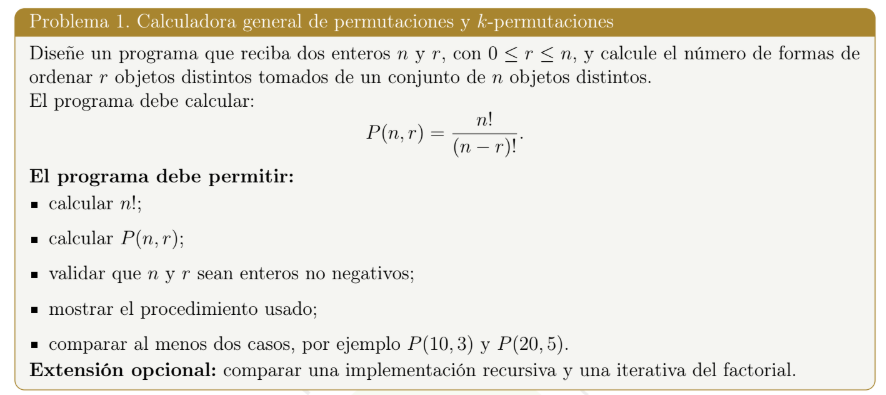

#1. Explicación del problema


---



El problema principal consiste en averiguar cuántas combinaciones o formas diferentes existen para ordenar un grupo pequeño de objetos ($r$) sacados de un grupo total más grande ($n$).

En este tipo de problemas, **el orden sí importa**. Por ejemplo, si elegimos las letras A y B, la organización "A-B" cuenta como una opción totalmente distinta a "B-A". El programa debe calcular esto automáticamente, permitir hacer varios cálculos seguidos y asegurarse de que el usuario no ingrese datos imposibles.

#2. Formula o principio combinatorio usado


---



Para resolver este proyecto nos basamos en dos conceptos matemáticos:

### El Factorial ($n!$)
Es la multiplicación de un número por todos los anteriores a él hasta llegar al uno.
$$n! = n \times (n-1) \times (n-2) \times \dots \times 1$$

* **Caso especial:** Por regla matemática, el factorial de cero es uno ($0! = 1$). Esto es súper importante en el código para que cuando restemos $n - r$ y nos dé cero, el programa no intente dividir entre cero y no rompa la aplicación.

### La Permutación ($k$-permutación)
Es la fórmula que nos dice cuántos arreglos ordenados se pueden hacer:
$$P(n, r) = \frac{n!}{(n-r)!}$$

Donde:
* $n!$ es el total de formas de ordenar todo el grupo completo.
* $(n-r)!$ sirve para "borrar" del cálculo los elementos que decidimos dejar por fuera, ya que su orden no nos interesa para el resultado final.

#3. Algoritmo implementado


---





El código está dividido en varias funciones sencillas en Python que se conectan entre sí. Funciona siguiendo estos pasos:

* **Bienvenida y Menú:** Al arrancar, el programa muestra un banner de presentación y abre un menú con 6 opciones (del 0 al 5). Usamos un bloque `try/except` para que si el usuario mete una letra por error o un número que no va, el programa no se cierre, sino que le diga "Opción inválida" y le vuelva a preguntar.
* **Filtro de datos (`ingresarvalores`):** Esta función pide los números $n$ y $r$. Tiene un colador lógico (`if r >= 0 and n >= 0 and r <= n`) que frena al usuario si intenta poner números negativos o si se le ocurre decir que $r$ es más grande que $n$.
* **Los dos motores de factorial:** * `nFactorial(n)` hace el cálculo mostrando el paso a paso en pantalla (ej: $1 \times 2 \times 3 = 6$) para que se vea el proceso.
  * `factorialnumero(n)` hace exactamente lo mismo pero en silencio, para que las otras funciones lo usen rápido sin llenar la pantalla de texto.

* **Los dos motores de permutación:** * `permutacion(n, r)` calcula los resultados y se encarga de "dibujar" una fracción matemática real en la consola usando guiones (`--------`) y alineando los textos al centro (`^8`) para que el usuario vea el desglose paso a paso.
  * `permutacionNumero(n, r)` hace la misma operación matemática combinatoria pero de forma "silenciosa" (sin dibujos). Está optimizada para que la opción de cálculos múltiples procese lotes de datos rápidamente sin llenar la pantalla de texto innecesario.
* **Cálculos en lote (Historiales):** Las opciones de cálculos múltiples dejan que el usuario haga varias operaciones una detrás de otra. El programa va guardando todo en listas y diccionarios y, al final, saca una tablita limpia con el resumen de todo lo que calculaste.
* **Prueba de velocidad (Rendimiento):** La opción 5 mide en microsegundos reales cuánto tarda el procesador usando un ciclo `for` (iterativo) contra la lógica recursiva (una función que se llama a sí misma). Además, tiene un escudo contra errores (`except RecursionError`) para demostrar que si le pides un número demasiado grande a la recursividad, la memoria de la computadora se satura (*Stack Overflow*) y falla, cosa que no le pasa al ciclo `for`.



#4. Codigo Funcional

Funciones


---



In [ ]:
import time
import sys

def ingresarvalores():
    """
    Solicita al usuario los valores enteros de 'n' y 'r' por consola.
    Aplica un bucle de validación robusto con try-except para evitar caracteres alfabéticos
    y restringe matemáticamente que r sea menor o igual a n, y ambos no negativos.
    Devuelve:
        (n, r) siendo n y r enteros validados correctamente.
    """
    print("Definición: 'n' es el total del conjunto y 'r' es el número de objetos a seleccionar (r <= n).")

    while True:
        try:
            n = int(input("Ingrese el valor total del conjunto (n): "))
            r = int(input("Ingrese el valor de objetos a seleccionar (r): "))

            # Validación de que sean positivos y que r no sea mayor que n
            if r >= 0 and n >= 0 and r <= n:
                break
            else:
                print("Asegúrate de que ambos sean positivos y que 'r' sea menor o igual que 'n'.\n")

        except ValueError:
            print("Por favor, ingresa solo números enteros.\n")

    return n,r

def bienvenida():
    """
    Imprime en la terminal el encabezado estético y la presentación del programa.
    """
    # Usamos triple comilla para hacer un bloque de texto largo y limpio
    texto = """
-----------------------------------------------------------------------------------------------------------------
                             CALCULADORA GENERAL DE PERMUTACIONES Y K-PERMUTACIONES
-----------------------------------------------------------------------------------------------------------------

Este programa nos permite calcular n! y P(n,r) siendo 'n' el total del conjunto y 'r' el número de objetos a seleccionar (r <= n)


"""
    print(texto)

def menu():
    """
    Despliega las 6 opciones disponibles en el sistema (0 a 5) y captura la selección.
    Garantiza mediante un bucle de control que la opción elegida sea un entero válido.
    Retorna:
        int: Número de opción seleccionada (0-5).
    """
    print("..................................................")
    print("                     MENÚ")
    print("..................................................\n")

    print("0. Salir del programa")
    print("1. Calcular un factorial (n!)")
    print("2. Calcular una Permutacion (P(n,r))")
    print("3. Calcular multiples factoriales (n!)")
    print("4. Calcular multiples permutaciones (P(n,r))")
    print("5. Comparación de la implementación recursiva e iterativa de factorial")

    while True:
        try:
            x = int(input("\n\nEscriba la opcion que desea realizar: "))
            if x in [0, 1, 2, 3, 4, 5]:
                break
            else:
                print("Opción inválida. Por favor, elige 0, 1, 2, 3, 4 o 5.\n")
        except ValueError:
            print("Por favor, ingresa solo números enteros.\n")

    if x == 0:
        print("\n-----------------------------------------------------------------------------------------------------------------")
        print("                                                    FIN PROGRAMA")
        print("-----------------------------------------------------------------------------------------------------------------")

    elif x == 1:
        print("\n-----------------------------------------------------------------------------------------------------------------")
        print("                                      Opcion 1. Calcular un factorial (n!)")
        print("-----------------------------------------------------------------------------------------------------------------")

    elif x == 2:
        print("\n-----------------------------------------------------------------------------------------------------------------")
        print("                                     Opcion 2. Calcular una Permutacion (P(n,r))")
        print("-----------------------------------------------------------------------------------------------------------------")

    elif x == 3:
        print("\n-----------------------------------------------------------------------------------------------------------------")
        print("                                     Opcion 3. Calcular multiples factoriales (n!)")
        print("-----------------------------------------------------------------------------------------------------------------")

    elif x == 4:
        print("\n-----------------------------------------------------------------------------------------------------------------")
        print("                                     Opcion 4. Calcular multiples permutaciones (P(n,r))")
        print("-----------------------------------------------------------------------------------------------------------------")

    elif x == 5:
        print("\n-----------------------------------------------------------------------------------------------------------------")
        print("                        Opcion 5. Comparación de la implementación recursiva e iterativa de factorial")
        print("-----------------------------------------------------------------------------------------------------------------")

    return x

def nFactorial(n):
    """
    Calcula de manera iterativa el factorial de un número entero n y muestra en pantalla
    el procedimiento de multiplicaciones paso a paso (ej: 1 * 2 * 3 = 6).
    Args:
        n (int): Número base.
    Retorna:
        int: El resultado del factorial calculado.
    """
    print(f'El factorial de {n} es:\n')
    x = 1

    for i in range(1, n + 1):
        x = x * i

        if i < n:
            print(i, end=" * ")
        else:
            print(i, end=" = ")

    print(x)
    return x

#implementacion iterativa de factorial
def factorialnumero(n):
    """
    Calcula el factorial de forma iterativa y silenciosa (sin prints intermedios).
    Optimizado para ser el motor matemático de las permutaciones rápidas.
    Argumentos:
        n (int): Número entero positivo.
    Retorna:
        int: Resultado de n!.
    """
    x = 1
    for i in range(1, n + 1):
        x = x * i
    return x

#implementacion recursiva factorial
def factorial_recursivo(n):
    """
    Calcula el factorial utilizando un enfoque de recursividad .
    Implementa un caso base (n <= 1) para detener la propagación de llamadas.
    Argumentos:
        n (int): Número entero positivo.
    Retorma:
        int: Resultado de n! obtenido recursivamente.
    """
    if n == 0 or n == 1:
        return 1
    else:
        return n * factorial_recursivo(n - 1)

def permutacionNumero(n,r):
    """
    Realiza el cálculo aritmético directo de una permutación usando división entera.
    """
  return(factorialnumero(n)//factorialnumero(n-r))

def permutacion(n,r):
    """
    Desarrolla el algoritmo principal de k-permutaciones. Calcula los factoriales
    necesarios y renderiza de forma gráfica en la consola la sustitución en la fórmula
    alineando dinámicamente numeradores y denominadores en formato de fracción.
    Argumentos:
        n (int): Total del conjunto.
        r (int): Objetos a seleccionar.
    Retorna:
        int: El resultado numérico de P(n, r).
    """

    formula = """
Fórmula de la Permutación P(n, r):

               n!
P(n, r) = ------
              (n-r)!
    """
    print(formula)

    print(f"En nuestro ejercicio n={n}, r={r}\n")
    print(f"n-r = {n}-{r} = {n-r}")
    print("\n\nAhora vamos a hallar los factoriales")
    print("\nFórmula de la Permutación P(n, r):\n")


    fn = factorialnumero(n)
    fnr = factorialnumero(n - r)
    res = fn // fnr


    # (Numeradores)
    num_1 = f"{'n!':^8}"
    num_2 = f"{str(n) + '!':^8}"
    num_3 = f"{str(n) + '!':^8}"
    num_4 = f"{fn:^8}"

    #(Denominadores)
    den_1 = f"{'(n-r)!':^8}"
    den_2 = f"{'(' + str(n) + '-' + str(r) + ')!':^8}"
    den_3 = f"{str(n-r) + '!':^8}"
    den_4 = f"{fnr:^8}"

    barra = "--------"

    # 3. Ensamblamos
    linea_superior = f"            {num_1}   {num_2}   {num_3}   {num_4}"
    linea_central  = f"  P({n}, {r}) = {barra} = {barra} = {barra} = {barra} = {res}"
    linea_inferior = f"            {den_1}   {den_2}   {den_3}   {den_4}"

    # 4. Imprimimos
    print(linea_superior)
    print(linea_central)
    print(linea_inferior)

    print (f'\nEl resultado de P({n},{r}) es: {res}')

    return res

def multiples_factoriales():
    """
    Gestiona un flujo iterativo masivo de factoriales. Solicita una cantidad inicial,
    ejecuta capturas cíclicas y almacena el histórico en un diccionario para mostrar un
    resumen tabulado final.
    """
    print("\n--- MÚLTIPLES FACTORIALES ---")
    cantidad = int(input("¿Cuántos factoriales deseas calcular en total?: "))


    historial_factoriales = []

    for i in range(1, cantidad + 1):
        print(f"\n-> Factorial #{i}:")
        n = int(input(f"  Ingrese el valor de n: "))

        resultado = factorialnumero(n)

        historial_factoriales.append({"n": n, "resultado": resultado})

    print("\n" + "="*20 + " RESUMEN DE FACTORIALES " + "="*20)
    for registro in historial_factoriales:
        print(f" El factorial de {registro['n']}! es igual a: {registro['resultado']}")
    print("="*64)

def multiples_permutaciones():
    """
    Gestiona un flujo iterativo masivo de permutaciones recopilando las coordenadas (n, r).
    Imprime el procedimiento de cada una y genera un cuadro resumen ordenado al finalizar.
    """
    print("\n--- MÚLTIPLES PERMUTACIONES ---")
    cantidad = int(input("¿Cuántas permutaciones deseas calcular en total?: "))

    historial_permutaciones = []

    for i in range(1, cantidad + 1):
        print(f"\n" + ".."*50)
        print(f"            CALCULANDO PERMUTACIÓN #{i}")
        print(".."*50)

        n,r = ingresarvalores()

        resultado = permutacion(n,r)

        historial_permutaciones.append({"n": n, "r": r, "resultado": resultado})

    print("\n" + "="*20 + " RESUMEN DE PERMUTACIONES " + "="*20)
    for reg in historial_permutaciones:
        print(f" P({reg['n']}, {reg['r']}) tiene un resultado de: {reg['resultado']}")
    print("="*66)

def comparar_metodos_factorial():
    """
    Módulo de análisis de rendimiento informático. Mide con precisión milimétrica (time.perf_counter)
    los microsegundos consumidos por la versión iterativa vs la recursiva. Cuenta con un interceptor
    'RecursionError' para demostrar los límites críticos de memoria del enfoque recursivo.
    """
    print("\n" + "="*25 + " MÓDULO DE COMPARACIÓN DE MÉTODOS " + "="*25)
    print("Vamos a evaluar la eficiencia de la versión Iterativa (For) vs la Recursiva.\n")

    try:
        n = int(input("Ingrese el número 'n' para la prueba de velocidad: "))
        if n < 0:
            print(" Por favor, ingrese un número positivo.")
            return
    except ValueError:
        print(" Ingrese solo números enteros.")
        return

    # 1. PRUEBA ENFOQUE ITERATIVO
    inicio_iterativo = time.perf_counter()  # Cronómetro inicia
    resultado_iterativo = factorialnumero(n)
    fin_iterativo = time.perf_counter()     # Cronómetro frena
    tiempo_iterativo = (fin_iterativo - inicio_iterativo) * 1000000 # Convertimos a microsegundos

    # 2. PRUEBA ENFOQUE RECURSIVO
    try:
        inicio_recursivo = time.perf_counter()
        resultado_recursivo = factorial_recursivo(n)
        fin_recursivo = time.perf_counter()
        tiempo_recursivo = (fin_recursivo - inicio_recursivo) * 1000000
        error_recursivo = False
    except RecursionError:
        error_recursivo = True

    # 3. IMPRESIÓN
    print("\n" + "-"*30 + " REPORTE DE TIEMPOS " + "-"*30)
    print(f"Tiempo Iterativo (Ciclo For): {tiempo_iterativo:.2f} microsegundos")

    if error_recursivo:
        print(f"Tiempo Recursivo: ¡ERROR! Exceso de límite de recursividad (RecursionError)")
    else:
        print(f"Tiempo Recursivo: {tiempo_recursivo:.2f} microsegundos")
    print("-"*80)

    # 4. CONCLUSIÓN
    print("\n ANÁLISIS DEL EXPERIMENTO:")
    if error_recursivo:
        print(f"-> Para n={n}, el método ITERATIVO ganó por knockout técnico.")
        print("   La recursividad falló porque Python tiene un límite de llamadas consecutivas en memoria para evitar colapsar la PC.")
    else:
        print(f"-> Ambos métodos llegaron al mismo resultado numérico.")
        if tiempo_iterativo < tiempo_recursivo:
            print(f"   El método ITERATIVO fue más rápido por una diferencia de {tiempo_recursivo - tiempo_iterativo:.2f} microsegundos.")
            print("   Esto ocurre porque la recursividad gasta tiempo abriendo y cerrando múltiples funciones en la memoria interna.")
        else:
            print(f"   El método RECURSIVO fue ligeramente más rápido en esta ocasión por {tiempo_iterativo - tiempo_recursivo:.2f} microsegundos.")
            print("   (En números muy pequeños, la diferencia de velocidad puede variar por procesos en segundo plano de la PC).")

    print("="*80 + "\n")



#4. Codigo Funcional
Programa Principal






In [ ]:
def calculadora():
    """
    Función de control maestro (orquestador principal). Inicializa la interfaz de bienvenida
    y administra el bucle infinito del ciclo de vida de la aplicación basándose en la opción del menú.
    """

    bienvenida()

    while True:
        opcion = menu()

        if opcion == 0:
            break

        elif opcion == 1:
            n = int(input("Ingrese el valor total (n) para calcular su factorial: "))
            nFactorial(n)
            print("\n" + "="*50 + "\n")

        elif opcion == 2:
            n,r = ingresarvalores()
            permutacion(n,r)
            print("\n" + "="*50 + "\n")

        elif opcion == 3:
            multiples_factoriales()
            print("\n" + "="*50 + "\n")

        elif opcion == 4:
            multiples_permutaciones()
            print("\n" + "="*50 + "\n")

        elif opcion == 5:
            comparar_metodos_factorial()
            print("\n" + "="*50 + "\n")

calculadora()




-----------------------------------------------------------------------------------------------------------------
                             CALCULADORA GENERAL DE PERMUTACIONES Y K-PERMUTACIONES
-----------------------------------------------------------------------------------------------------------------

Este programa nos permite calcular n! y P(n,r) siendo 'n' el total del conjunto y 'r' el número de objetos a seleccionar (r <= n)



..................................................
                     MENÚ
..................................................

0. Salir del programa
1. Calcular un factorial (n!)
2. Calcular una Permutacion (P(n,r))
3. Calcular multiples factoriales (n!)
4. Calcular multiples permutaciones (P(n,r))
5. Comparación de la implementación recursiva e iterativa de factorial


Escriba la opcion que desea realizar: 0

-----------------------------------------------------------------------------------------------------------------
                       

#5. Pruebas


---



### Prueba 1: Caso P(10, 3)

* Opción seleccionada en el menú: Opción 2 (Calcular una Permutacion (P(n,r))) o Opción 4 (Calcular multiples permutaciones (P(n,r)))

* Datos ingresados: Total del conjunto ($n$) = 10, Objetos a seleccionar ($r$) = 3

* Procedimiento en pantalla: El programa calcula $10 - 3 = 7$. Luego, muestra gráficamente cómo divide $10!$ entre $7!$.

* Resultado obtenido: 720

* Significado: Hay 720 formas diferentes de organizar 3 objetos tomados de un grupo de 10.



### Prueba 2: Caso P(20, 5)

* Opción seleccionada en el menú: Opción 2 (Calcular una Permutacion (P(n,r))) o Opción 4 (Calcular multiples permutaciones (P(n,r)))

* Datos ingresados: Total del conjunto ($n$) = 20, Objetos a seleccionar ($r$) = 5

* Procedimiento en pantalla: El programa calcula $20 - 5 = 15$. Luego, muestra gráficamente cómo divide $20!$ entre $15!$.

* Resultado obtenido: 1860480

* Significado: Hay 1860480 formas diferentes de organizar 5 objetos tomados de un grupo de 20



### Prueba 3: Caso Especial de Selección Completa P(5, 5)

* Opción seleccionada en el menú: Opción 2 (Calcular una Permutacion (P(n,r))) o Opción 4 (Calcular multiples permutaciones (P(n,r)))

* Datos ingresados: Total del conjunto ($n$) = 5, Objetos a seleccionar ($r$) = 5

* Procedimiento en pantalla: El programa calcula $5 - 5 = 0$. Luego, muestra gráficamente cómo divide $5!$ ($120$) entre $0!$ ($1$).

* Resultado obtenido: 120

* Significado: Demuestra que ordenar todos los elementos ($n = r$) equivale matemáticamente a calcular simplemente el factorial puro del conjunto ($5!$).



### Prueba 4: Caso Especial de Elemento Neutro P(8, 0)

* Opción seleccionada en el menú: Opción 2 (Calcular una Permutacion (P(n,r))) o Opción 4 (Calcular multiples permutaciones (P(n,r)))

* Datos ingresados: Total del conjunto ($n$) = 8, Objetos a seleccionar ($r$) = 0

* Procedimiento en pantalla: El programa calcula $8 - 0 = 8$. Luego, muestra gráficamente cómo divide $8!$ entre $8!$.

* Resultado obtenido: 1

* Significado: Validación correcta del caso base combinatorio; solo existe 1 forma única de organizar cero elementos (dejar el grupo vacío).



### Prueba 5: Caso de Valores Mínimos P(1, 1)

* Opción seleccionada en el menú: Opción 2 (Calcular una Permutacion (P(n,r))) o Opción 4 (Calcular multiples permutaciones (P(n,r)))

* Datos ingresados: Total del conjunto ($n$) = 1, Objetos a seleccionar ($r$) = 1

* Procedimiento en pantalla: El programa calcula $1 - 1 = 0$. Luego, muestra gráficamente cómo divide $1!$ ($1$) entre $0!$ ($1$).

* Resultado obtenido: 1

* Significado: Comprobación exitosa de los límites inferiores de la calculadora.

#6. Validación casos especiales


---



El software cuenta con un sistema de control de excepciones robusto ante los escenarios anómalos clásicos:

*  Entradas no numéricas (Cadenas/Letras): Si el usuario digita "diez" o "cinco", el bloque except ValueError intercepta el fallo e impide que el hilo de ejecución colapse, solicitando de nuevo las entradas.

*  Restricción matemática estricta ($r > n$): Si un usuario intenta calcular $P(3, 5)$ (seleccionar 5 objetos de un total de 3), el validador condicional rechaza la entrada imprimiendo un mensaje de advertencia aclaratorio, rompiendo la vulnerabilidad de factoriales negativos.

*  Números Negativos: Entradas como $n = -5$ o $r = -2$ son bloqueadas en la misma capa lógica asegurando consistencia matemática.

#7. Eficiencia del algoritmo


---



El análisis del algoritmo arroja las siguientes conclusiones técnicas:

*  Complejidad Temporal: El cálculo iterativo del factorial se ejecuta en un tiempo lineal $\mathcal{O}(n)$, ya que requiere un único bucle que realiza $n$ multiplicaciones sucesivas. Para calcular la permutación completa, la complejidad sigue siendo $\mathcal{O}(n)$, lo cual la hace sumamente rápida y eficiente.

*  Complejidad Espacial (Memoria): La versión iterativa mantiene una complejidad espacial constante de $\mathcal{O}(1)$ porque reutiliza las mismas variables en la memoria caché local de la CPU.

*  Extensión - Iterativo vs. Recursivo: La prueba de rendimiento integrada (Opción 5) demuestra que el enfoque iterativo es superior para entornos de producción. Mientras que la recursividad requiere un espacio de memoria lineal $\mathcal{O}(n)$ debido a la acumulación de marcos en la pila de llamadas (generando un fallo crítico de desbordamiento RecursionError al superar aproximadamente las 1000 llamadas consecutivas), el ciclo iterativo puede procesar valores masivos sin sobrecargar los recursos físicos del sistema.